# A/B Test Analysis: ANOVA for Multi-Group Experiments

This notebook covers two ANOVA case studies:

**Part 1 — One-Way ANOVA** (`data/post_likes.csv`)  
A product team tested three button colors (red, green, blue) on a social media platform.  
Goal: determine whether button color significantly affects the number of post likes.

**Part 2 — Two-Way ANOVA** (`data/ads_clicks.csv`)  
A marketing team tested two ad styles (classic, bold) across three age groups.  
Goal: measure the effect of each factor and their interaction on click count.

**Topics:**
1. Dataset overview
2. Visual exploration
3. One-Way ANOVA — three approaches
4. ANOVA assumptions: normality
5. ANOVA assumptions: homogeneity of variance
6. Post-hoc pairwise comparisons
7. Two-Way ANOVA: main effects and interactions
8. Conclusion

## Part 1: One-Way ANOVA — Button Color vs. Post Likes

### Dataset Description

| Column | Type | Description |
|--------|------|-------------|
| `id` | str | Unique user identifier |
| `button` | str | Button color shown: `red`, `green`, or `blue` |
| `likes` | int | Number of likes the post received |

In [67]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.special import comb
import statsmodels.formula.api as smf
from statsmodels.stats.api import anova_lm
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 1. Dataset Overview

In [68]:
df = pd.read_csv('data/post_likes.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (300, 3)


,id,button,likes
0,S001,red,160
1,S002,red,150
2,S003,red,150
3,S004,red,150
4,S005,red,187


In [69]:
df.info()
print()
print('Group sizes:')
print(df['button'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      300 non-null    str  
 1   button  300 non-null    str  
 2   likes   300 non-null    int64
dtypes: int64(1), str(2)
memory usage: 7.2 KB

Group sizes:
button
red      100
green    100
blue     100
Name: count, dtype: int64


## 2. Visual Exploration

Before running any test, visualize the distributions across groups.
Box and violin plots reveal the center, spread, and shape of each group's distribution.

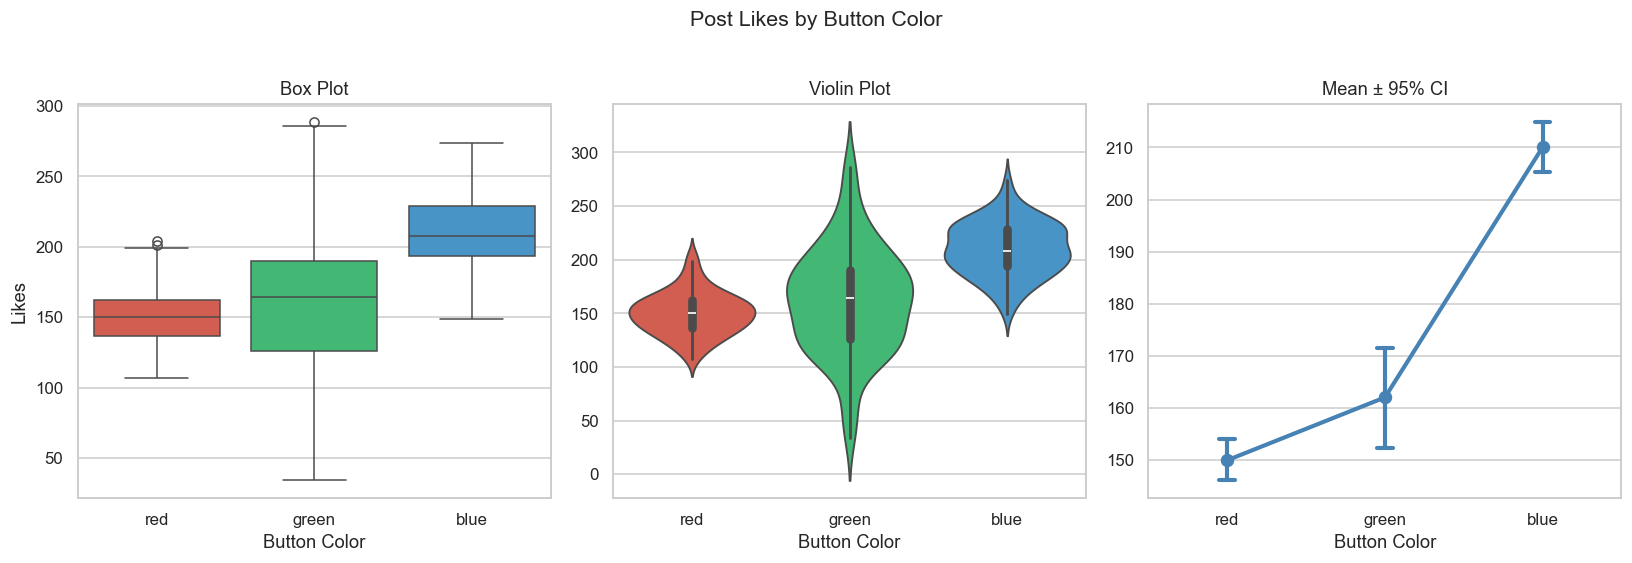

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

palette = {'red': '#e74c3c', 'green': '#2ecc71', 'blue': '#3498db'}

sns.boxplot(x='button', y='likes', hue='button', data=df, palette=palette, ax=axes[0], legend=False)
axes[0].set_title('Box Plot')
axes[0].set_xlabel('Button Color')
axes[0].set_ylabel('Likes')

sns.violinplot(x='button', y='likes', hue='button', data=df, palette=palette, ax=axes[1], legend=False)
axes[1].set_title('Violin Plot')
axes[1].set_xlabel('Button Color')
axes[1].set_ylabel('')

sns.pointplot(x='button', y='likes', data=df, ax=axes[2], color='steelblue', capsize=0.1)
axes[2].set_title('Mean ± 95% CI')
axes[2].set_xlabel('Button Color')
axes[2].set_ylabel('')

plt.suptitle('Post Likes by Button Color', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. One-Way ANOVA

**When to use ANOVA:** comparing means across 3 or more groups simultaneously.
Running multiple pairwise t-tests inflates the Type I error rate — ANOVA avoids this by testing all groups at once.

**Key idea:**  
ANOVA decomposes total variance into two components:
- **SSB** (between-group variance): how different the group means are from the overall mean
- **SSW** (within-group variance): natural variation inside each group

The **F-statistic** is the ratio of variance *between* groups to variance *within* groups, each adjusted by degrees of freedom:

$$F = \frac{SSB / (m-1)}{SSW / (N-m)}$$

A large F means between-group differences dominate within-group noise → groups are likely different.

**Hypotheses:**
- $H_0$: all group means are equal ($\mu_{red} = \mu_{green} = \mu_{blue}$)
- $H_1$: at least one group mean differs

Significance level: $\alpha = 0.05$

We demonstrate three equivalent implementations below.

In [71]:
red   = df.query('button == "red"').likes
green = df.query('button == "green"').likes
blue  = df.query('button == "blue"').likes

print('Group means:')
print(f'  red:   {red.mean():.2f}')
print(f'  green: {green.mean():.2f}')
print(f'  blue:  {blue.mean():.2f}')

Group means:
  red:   149.96
  green: 162.02
  blue:  210.03


In [72]:
# Approach 1: scipy
result = stats.f_oneway(red, green, blue)
print(f'F-statistic: {result.statistic:.4f}')
print(f'P-value:     {result.pvalue:.2e}')
print(f"=> {'Reject H₀' if result.pvalue < 0.05 else 'Fail to reject H₀'}")
print('\nThe F-statistic ≈ 86 means between-group variance is ~86× larger than within-group variance.')

F-statistic: 85.9963
P-value:     3.44e-30
=> Reject H₀

The F-statistic ≈ 86 means between-group variance is ~86× larger than within-group variance.


In [73]:
# Approach 2: statsmodels OLS (produces a full ANOVA table)
# C(button) tells the model to treat 'button' as a categorical variable
model = smf.ols(formula='likes ~ C(button)', data=df).fit()
anova_lm(model)

,df,sum_sq,mean_sq,F,PR(>F)
C(button),2.0,201960.286667,100980.143333,85.996311,3.437005e-30
Residual,297.0,348748.710000,1174.238081,NaN,NaN


In [74]:
# Approach 3: pingouin (includes eta-squared effect size)
# np2 (partial eta-squared): proportion of total variance explained by the group factor
pg.anova(data=df, dv='likes', between='button')

,Source,ddof1,ddof2,F,p_unc,np2
0,button,2,297,85.996311,3.437005e-30,0.366728


## 4. ANOVA Assumptions: Normality

One-Way ANOVA assumes the residuals within each group are approximately normally distributed.

- **Shapiro-Wilk** — reliable for small samples ($n < 50$); tends to over-reject for larger samples
- **D'Agostino-Pearson** (`normaltest`) — designed for larger samples; tests skewness and kurtosis jointly
- **QQ plot** — visual check; deviations from the diagonal line indicate non-normality

In [75]:
print('Shapiro-Wilk test (note: can over-reject for n > 50):')
for name, group in [('red', red), ('green', green), ('blue', blue)]:
    result = stats.shapiro(group)
    print(f'  {name}: W={result.statistic:.4f}, p={result.pvalue:.4f} => {"normal" if result.pvalue > 0.05 else "non-normal"}')

Shapiro-Wilk test (note: can over-reject for n > 50):
  red: W=0.9881, p=0.5159 => normal
  green: W=0.9887, p=0.5625 => normal
  blue: W=0.9938, p=0.9310 => normal


In [76]:
# D'Agostino-Pearson test via pingouin
pg.normality(data=df, dv='likes', group='button', method='normaltest')

,W,pval,normal
button,,,
red,1.834359,0.399645,True
green,0.672706,0.714371,True
blue,0.460696,0.794257,True


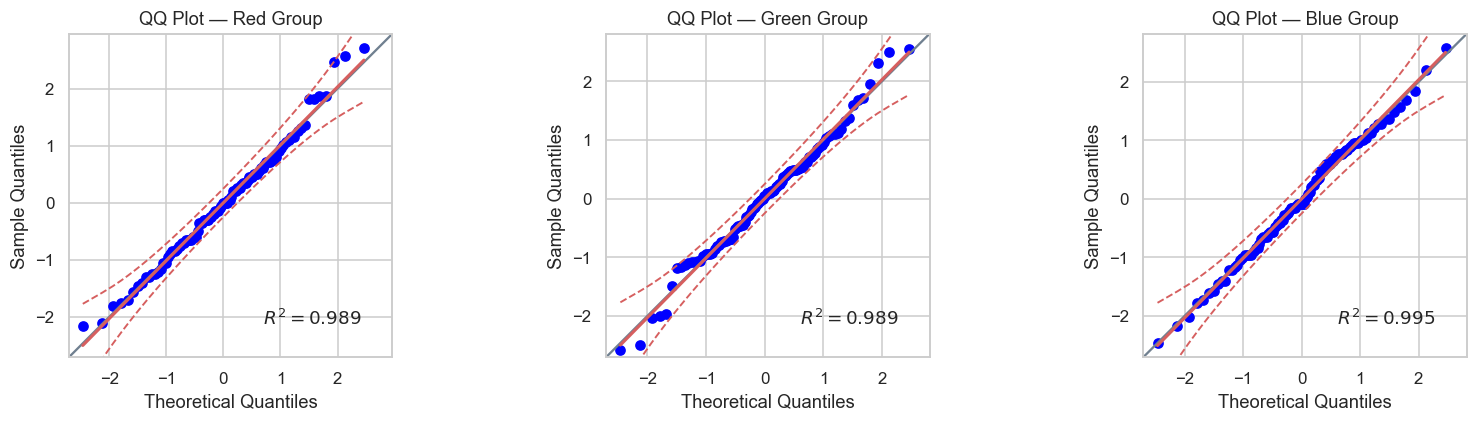

All three groups follow the reference line closely — normality assumption holds.


In [82]:
# QQ plots — visual normality check for each group
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Use pingouin's built-in qqplot for each group
for ax, (name, group) in zip(axes, [('red', red), ('green', green), ('blue', blue)]):
    pg.qqplot(group, ax=ax)
    ax.set_title(f'QQ Plot — {name.capitalize()} Group')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()
print('All three groups follow the reference line closely — normality assumption holds.')

## 5. ANOVA Assumptions: Homogeneity of Variance

Standard ANOVA assumes equal variances across groups (homoscedasticity).

**Levene's test** checks this:
- $H_0$: all group variances are equal
- $H_1$: at least one group has a different variance

If variances are unequal, use **Welch's ANOVA** — it does not require equal variances.

In [83]:
# Levene's test via scipy
result_lev = stats.levene(red, green, blue)
print(f'Levene statistic: {result_lev.statistic:.4f}')
print(f'P-value:          {result_lev.pvalue:.2e}')
print(f"=> {'Equal variances (homoscedastic)' if result_lev.pvalue > 0.05 else 'Unequal variances — use Welch ANOVA'}")

Levene statistic: 35.2143
P-value:          1.89e-14
=> Unequal variances — use Welch ANOVA


In [84]:
# Pingouin homoscedasticity test
pg.homoscedasticity(data=df, dv='likes', group='button')

,W,pval,equal_var
levene,35.214282,1.888664e-14,False


In [85]:
# Welch's ANOVA — does not assume equal variances
# Recommended when Levene's test rejects equal variances
pg.welch_anova(data=df, dv='likes', between='button')

,Source,ddof1,ddof2,F,p_unc,np2
0,button,2,182.958104,177.856578,1.255660e-43,0.366728


## 6. Post-hoc Pairwise Comparisons

ANOVA only tells us *that* at least one group differs — not *which* groups.
Post-hoc tests run all pairwise comparisons to identify where the differences lie.

**The multiple comparisons problem:**  
Each comparison has a 5% chance of a false positive. Running 3 comparisons simultaneously raises the overall Type I error rate:

$$P(\text{at least one false positive}) = 1 - (1-0.05)^3 \approx 14\%$$

**Correction methods:**
| Method | Description |
|--------|-------------|
| **Bonferroni** | Divide $\alpha$ by number of comparisons — conservative but simple |
| **Holm-Bonferroni** | Step-down version of Bonferroni — less conservative |
| **Benjamini-Hochberg** | Controls false discovery rate — most sensitive |
| **Games-Howell** | Preferred when group variances are unequal |

In [86]:
n_groups = 3
n_comparisons = comb(n_groups, 2)
family_error = 1 - 0.95 ** n_comparisons
bonferroni_threshold = 0.05 / n_comparisons

print(f'Number of pairwise comparisons for {n_groups} groups: {n_comparisons:.0f}')
print(f'Family-wise Type I error without correction: {family_error:.1%}')
print(f'Bonferroni-adjusted significance threshold:  {bonferroni_threshold:.4f}')

Number of pairwise comparisons for 3 groups: 3
Family-wise Type I error without correction: 14.3%
Bonferroni-adjusted significance threshold:  0.0167


In [87]:
# Pairwise t-tests without correction
pg.pairwise_tests(data=df, dv='likes', between='button')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,BF10,hedges
0,button,blue,green,False,True,8.591097,198.0,two-sided,2.561866e-15,2.025e+12,1.210357
1,button,blue,red,False,True,18.769214,198.0,two-sided,7.952330e-46,1.582e+42,2.644301
2,button,green,red,False,True,2.240189,198.0,two-sided,2.619001e-02,1.583,0.315609


In [88]:
# With Bonferroni correction — compare p_corr to 0.05
result_bonf = pg.pairwise_tests(data=df, dv='likes', between='button', padjust='bonf')
result_bonf[['A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'p_adjust', 'hedges']]
# Note: green vs red becomes non-significant after correction (p_corr ≈ 0.079 > 0.05)

,A,B,T,dof,p_unc,p_corr,p_adjust,hedges
0,blue,green,8.591097,198.0,2.561866e-15,7.685599e-15,bonf,1.210357
1,blue,red,18.769214,198.0,7.952330e-46,2.385699e-45,bonf,2.644301
2,green,red,2.240189,198.0,2.619001e-02,7.857004e-02,bonf,0.315609


In [89]:
# Games-Howell test — preferred when variances are unequal (as shown by Levene's test)
pg.pairwise_gameshowell(data=df, dv='likes', between='button')

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,blue,green,210.03,162.02,48.01,5.588343,8.591097,145.583529,2.131628e-14,1.210357
1,blue,red,210.03,149.96,60.07,3.200454,18.769214,188.902921,0.000000e+00,2.644301
2,green,red,162.02,149.96,12.06,5.383475,2.240189,129.889834,6.830241e-02,0.315609


**Part 1 Summary:**
- ANOVA finds a highly significant difference across the three button colors ($F ≈ 86$, $p \approx 0$)
- The button color explains ~37% of the total variance in likes (partial $\eta^2 = 0.37$)
- Post-hoc tests confirm blue is significantly different from both red and green
- Green vs. red is borderline: significant without correction, not significant after Bonferroni

---
## Part 2: Two-Way ANOVA — Ad Clicks by Style and Age Group

Two-Way ANOVA tests the effect of **two categorical factors** simultaneously and detects whether they **interact**.

### Dataset Description

| Column | Type | Description |
|--------|------|-------------|
| `id` | str | Unique user identifier |
| `ads` | str | Ad style: `classic` or `bold` |
| `age_group` | str | Age group: `18-27`, `28-45`, or `46 and more` |
| `clicks` | int | Number of ad clicks |

## 7. Dataset Overview

In [90]:
clicks = pd.read_csv('data/ads_clicks.csv')
print(f'Shape: {clicks.shape}')
clicks.head()

Shape: (600, 4)


,id,ads,age_group,clicks
0,S001,classic,18-27,40
1,S002,classic,18-27,22
2,S003,classic,18-27,41
3,S004,classic,18-27,35
4,S005,classic,18-27,39


In [91]:
print('Unique values per column:')
clicks.apply(lambda x: x.unique())

Unique values per column:


id           [S001, S002, S003, S004, S005, S006, S007, S00...
ads                                            [classic, bold]
age_group                          [18-27, 28-45, 46 and more]
clicks       [40, 22, 41, 35, 39, 57, 44, 43, 45, 32, 31, 3...
dtype: object

## 8. Main Effects Model (No Interaction)

The additive model estimates the effect of each factor independently, assuming they do not interact.

$$\text{clicks} \sim \text{ads} + \text{age\_group}$$

In [92]:
model_main = smf.ols('clicks ~ C(ads) + C(age_group)', data=clicks).fit()
anova_lm(model_main)

,df,sum_sq,mean_sq,F,PR(>F)
C(ads),1.0,33735.001667,33735.001667,68.810244,7.245176e-16
C(age_group),2.0,400495.163333,200247.581667,408.450696,1.950084e-112
Residual,596.0,292195.753333,490.261331,NaN,NaN


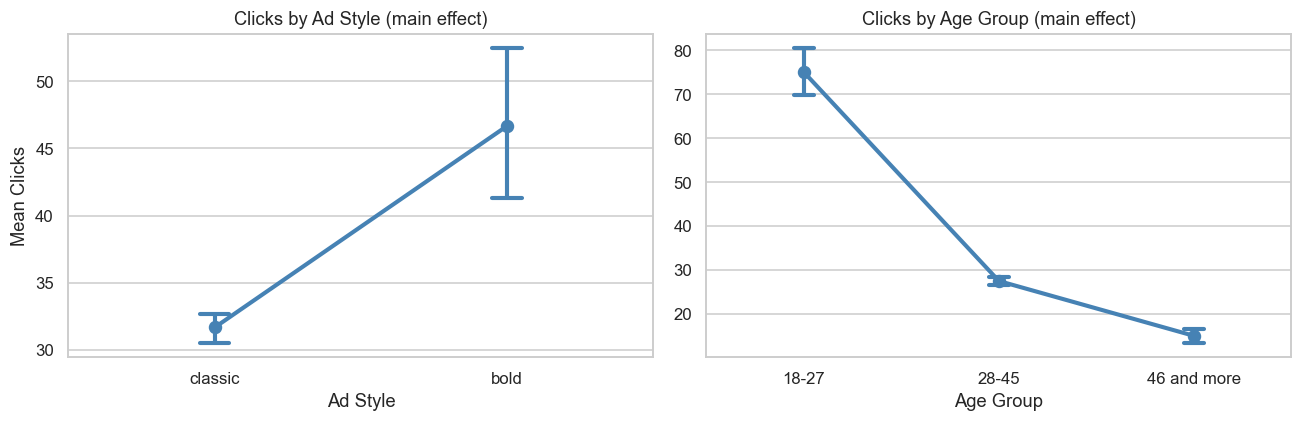

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.pointplot(x='ads', y='clicks', data=clicks, ax=axes[0], color='steelblue', capsize=0.1)
axes[0].set_title('Clicks by Ad Style (main effect)')
axes[0].set_xlabel('Ad Style')
axes[0].set_ylabel('Mean Clicks')

sns.pointplot(x='age_group', y='clicks', data=clicks, ax=axes[1], color='steelblue', capsize=0.1)
axes[1].set_title('Clicks by Age Group (main effect)')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 9. Interaction Effects Model

The interaction term tests whether the **effect of one factor depends on the level of the other**.
For example: does the bold ad perform better only for younger users?

$$\text{clicks} \sim \text{ads} \times \text{age\_group} = \text{ads} + \text{age\_group} + \text{ads} : \text{age\_group}$$

If the interaction term is significant, the main effects alone cannot tell the full story.

In [94]:
# * notation is shorthand for main effects + interaction
model_interact = smf.ols('clicks ~ C(ads) * C(age_group)', data=clicks).fit()
anova_lm(model_interact)

,df,sum_sq,mean_sq,F,PR(>F)
C(ads),1.0,33735.001667,33735.001667,336.722432,6.446773e-60
C(age_group),2.0,400495.163333,200247.581667,1998.750536,1.636934e-264
C(ads):C(age_group),2.0,232685.043333,116342.521667,1161.260853,5.618312e-206
Residual,594.0,59510.710000,100.186380,NaN,NaN


In [95]:
# Pingouin two-way ANOVA (includes partial eta-squared per factor)
pg.anova(data=clicks, dv='clicks', between=['ads', 'age_group'])

,Source,SS,DF,MS,F,p_unc,np2
0,ads,33735.001667,1,33735.001667,336.722432,6.446773e-60,0.361786
1,age_group,400495.163333,2,200247.581667,1998.750536,1.636934e-264,0.870631
2,ads * age_group,232685.043333,2,116342.521667,1161.260853,5.618312e-206,0.796333
3,Residual,59510.710000,594,100.186380,NaN,NaN,NaN


## 10. Visualizing the Interaction

An interaction plot shows how the effect of one factor changes across levels of the other.
**Non-parallel lines** indicate a statistically significant interaction.

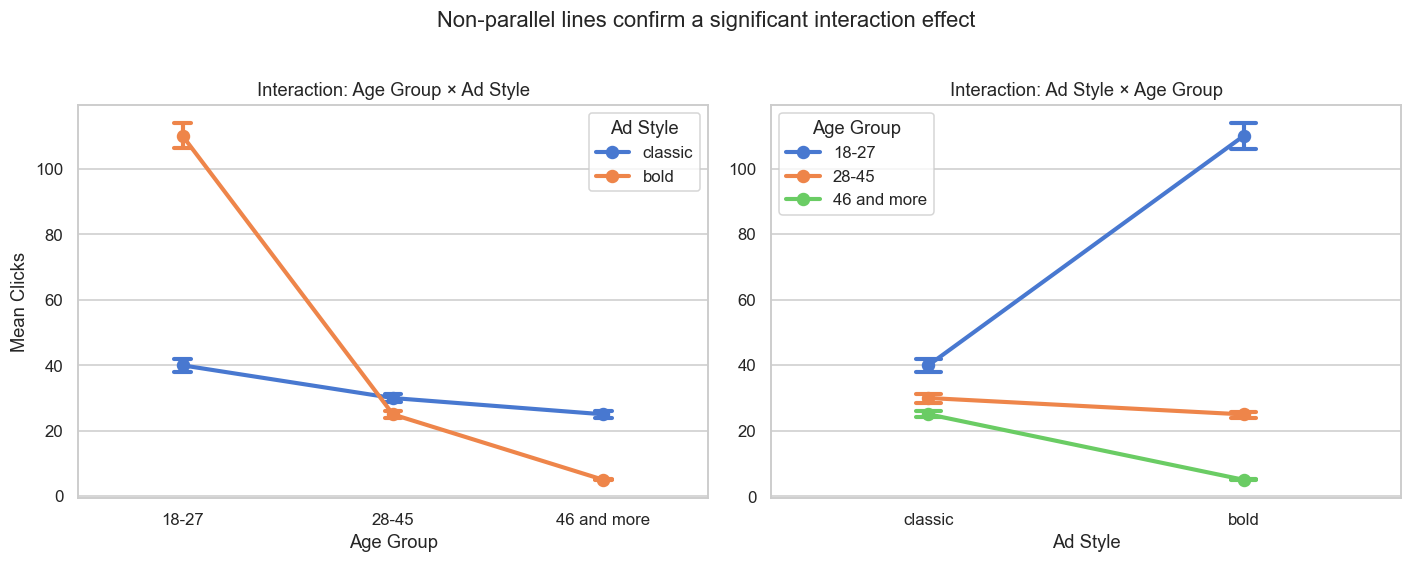

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ad style × age group
sns.pointplot(
    x='age_group', y='clicks', hue='ads',
    data=clicks, ax=axes[0], capsize=0.08,
    palette='muted'
)
axes[0].set_title('Interaction: Age Group × Ad Style')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Mean Clicks')
axes[0].legend(title='Ad Style')

# Age group × ad style (flipped)
sns.pointplot(
    x='ads', y='clicks', hue='age_group',
    data=clicks, ax=axes[1], capsize=0.08,
    palette='muted'
)
axes[1].set_title('Interaction: Ad Style × Age Group')
axes[1].set_xlabel('Ad Style')
axes[1].set_ylabel('')
axes[1].legend(title='Age Group')

plt.suptitle('Non-parallel lines confirm a significant interaction effect', y=1.02)
plt.tight_layout()
plt.show()

## Conclusion

### Part 1: One-Way ANOVA — Button Color

- ANOVA strongly rejects $H_0$ ($F \approx 86$, $p \approx 10^{-30}$)
- Button color explains **~37%** of variance in post likes ($\eta^2 = 0.37$)
- **Blue** generates significantly more likes than red or green
- **Green vs. red** difference vanishes after Bonferroni correction (borderline effect)
- Use **Welch ANOVA + Games-Howell** since Levene's test detected unequal variances

### Part 2: Two-Way ANOVA — Ad Clicks

- Both **ad style** and **age group** are significant main effects
- The **interaction term** is highly significant — the effect of ad style *depends on* age group
- The additive model is insufficient; the interaction must be included
- Partial $\eta^2$ shows age group explains ~87% of variance, while the interaction explains ~80%

**Key takeaway:** Always check for interaction effects in multi-factor experiments before interpreting main effects in isolation.

---
## Practice Problems

**Problem 1.** To find the best teaching method, students were split into 5 groups, each taught using a different approach. At year-end, all groups took a final exam. One-Way ANOVA rejected $H_0$ (equal means).  
How many pairwise comparisons are needed to compare all groups?

In [97]:
n = comb(5, 2)
print(f'Number of pairwise comparisons for 5 groups: {n:.0f}')

Number of pairwise comparisons for 5 groups: 10


**Problem 2.** Researchers studied lung function in three groups: non-smokers, passive smokers, and active smokers.  
ANOVA rejected $H_0$ at $p < 0.05$. A Bonferroni correction was applied for pairwise comparisons.  
What is the corrected significance threshold?

In [98]:
k = comb(3, 2)
alpha_corrected = 0.05 / k
print(f'Number of comparisons: {k:.0f}')
print(f'Bonferroni-adjusted α: {alpha_corrected:.4f}')

Number of comparisons: 3
Bonferroni-adjusted α: 0.0167
